In [19]:
import numpy             as np
import scipy.signal      as signal
import matplotlib.pyplot as plt
import soundfile         as sf
import librosa           

In [20]:
# carregar o áudio
y, sr = librosa.load('sinal_musical_com_ruido_rosa.wav', sr=44100)  # Carrega a 44.1 kHz

# taxa de amostragem para 16 kHz
y_resampled = librosa.resample(y, orig_sr=sr, target_sr=16000)

# áudio redimensionado
sf.write('audio_16kHz.wav', y_resampled, 16000)

# sinal de áudio a 16kHz
audio, fs = sf.read('audio_16kHz.wav')

In [21]:
# parâmetros do filtro
fc = 430  # frequência de corte (Hz)
norm_fc = fc / (fs / 2)  # normalizada

In [22]:
# FIR - janela de Hamming
fir_order = 101
fir_coeff = signal.firwin(fir_order + 1, norm_fc, window='hamming', pass_zero='lowpass')

In [23]:
# IIR - Butterworth 4ª ordem
iir_order = 10
b_iir, a_iir = signal.butter(iir_order, norm_fc,btype='lowpass')

In [24]:
# aplicação dos filtros
audio_fir = signal.lfilter(fir_coeff, 1.0, audio)
audio_iir = signal.lfilter(b_iir, a_iir, audio)

# salva arquivos filtrados
sf.write("audio_fir_filtrado_rosa.wav", audio_fir, fs)
sf.write("audio_iir_filtrado_rosa.wav", audio_iir, fs)

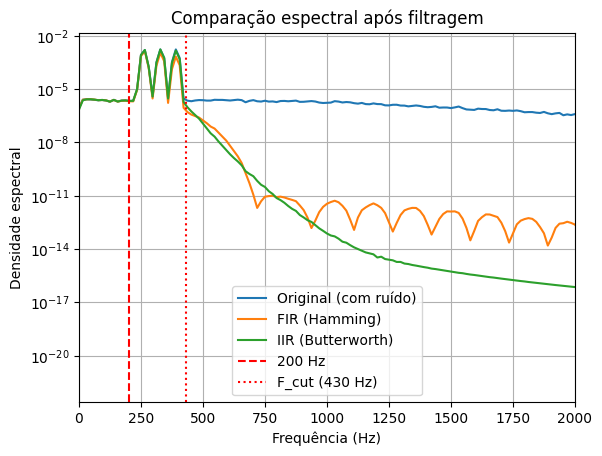

In [25]:
# espectros
f, Pxx_audio = signal.welch(audio, fs, nperseg=1024)
f, Pxx_fir = signal.welch(audio_fir, fs, nperseg=1024)
f, Pxx_iir = signal.welch(audio_iir, fs, nperseg=1024)


# Plot
plt.semilogy(f, Pxx_audio, label='Original (com ruído)')
plt.semilogy(f, Pxx_fir, label='FIR (Hamming)')
plt.semilogy(f, Pxx_iir, label='IIR (Butterworth)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Densidade espectral')
plt.axvline(x=200, color='r', linestyle='--', label='200 Hz')
plt.axvline(x=430, color='r', linestyle=':', label='F_cut (430 Hz)')
plt.legend()
plt.title('Comparação espectral após filtragem')
plt.grid()
plt.xlim(0, 2000)
plt.show()


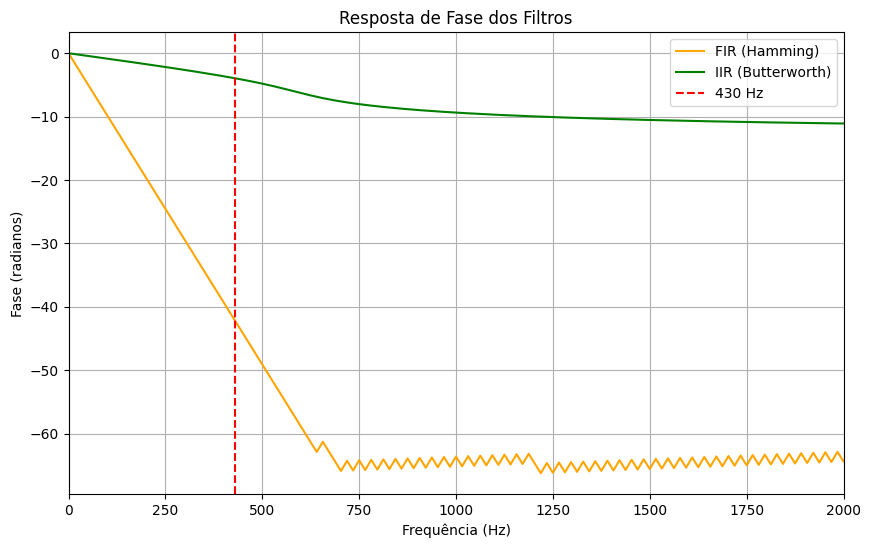

In [26]:
# FIR
fir_coeff = signal.firwin(501, 600/(16000/2), window='hamming')
w_fir, h_fir = signal.freqz(fir_coeff, fs=16000)
phase_fir = np.unwrap(np.angle(h_fir))

# IIR
b_iir, a_iir = signal.butter(8, 600/(16000/2), btype='lowpass')
w_iir, h_iir = signal.freqz(b_iir, a_iir, fs=16000)
phase_iir = np.unwrap(np.angle(h_iir))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(w_fir, phase_fir, label='FIR (Hamming)', color='orange')
plt.plot(w_iir, phase_iir, label='IIR (Butterworth)', color='green')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Fase (radianos)')
plt.axvline(x=430, color='red', linestyle='--', label='430 Hz')
plt.legend()
plt.grid()
plt.xlim(0, 2000)
plt.title('Resposta de Fase dos Filtros')
plt.show()

<p style="text-align: justing;">Um filtro tem fase linear na banda de passagem quando o atraso de fase introduzido pelo filtro varia linearmente com a frequência, ou seja, quando a derivada primeira da fase em função da frequência resulta em uma constante. Matematicamente, isso significa que a fase obedece a:</p>

$${\phi(\omega) = -D \cdot \omega + C}~~~~~~~~~~~~~~~~~~~~~~~~~~~(1)$$

onde:

- $D$ é o atraso de grupo constante(em segundos),
- $C$ é uma constante(geralmente 0 ou multiplo de $\pi$),
- $\omega$ é a frequência angular. 

<div style="text-align: justing;">

**IMPLICAÇÕES PRÁTICAS**  
• Preservação da forma de onda, ou seja, sinais na banda de passagem **não sofrem distorção de fase**, ou ainda: componentes de frequêcia diferentes são atrasados pelo mesmo tempo.

• Para que a derivada em $(1)$ seja constante, ou melhor, o **Atraso de grupo constante** os filtros devem apresentar resposta de fase linear, que nesse caso apenas o filtro FIR atende ao este requisito.

• A distorção de fase, ou ainda, a não-linearidade no atraso das diferentes componentes de frequência gera "sujeiras(*smearing*)" nos transientes dos sinais.

• Em contra partida, a não linearidade dos filtros IIR na música é útil para o "Tempero Artístico": pode-se reforçar(+gain) ou atenuar(-gain) em uma determinada frequência, a não linearidade também é ideal para projetos de sintetizadores digitais e efeitos sonoros mais diversos, onde "bagunçar" a fase dos frequência é o objetivo.

• Filtros IIR, também são últeis para sistemas embarcados, devido ao seu significativo número reduzido de coeficiêntes.

</div>

# IIR $\times$ FIR #

| Característica               | IIR                            | FIR                            |
|------------------------------|--------------------------------|--------------------------------|
| **Número de coeficientes**    | ✅ Menos para mesma atenuação  | ❌ Precisa de mais coeficientes |
| **Fase**                     | ❌ Não linear (distorção temporal) | ✅ Linear (preserva forma de onda) |
| **Atraso de processamento**  | ✅ Baixo                       | ❌ Alto (depende da ordem)     |
| **Estabilidade numérica**    | ❌ Risco de instabilidade      | ✅ Inerentemente estável       |
| **Eficiência em hardware**   | ✅ Alta (DSP/FPGA)             | ❌ Consome mais recursos       |
| **Projeto de fase linear**   | ❌ Difícil                     | ✅ Fácil                       |



### **Referências Técnicas sobre Filtros FIR/IIR em Smartphones**  

#### **1. Processamento de Imagem Geral**  
- **Gonzalez & Woods, *Digital Image Processing***  
  - Capítulos sobre filtros digitais (FIR/IIR) e aplicações em fotografia computacional.  
  - [Link para o livro](https://www.pearson.com/store/p/digital-image-processing/P100001672841)  

- **IEEE Xplore - Filtros em Dispositivos Móveis**  
  - Artigos sobre implementação de filtros FIR/IIR em câmeras de smartphones.  
  - [IEEE Xplore Search](https://ieeexplore.ieee.org/)  

#### **2. Apple (iPhone)**  
- **Apple Developer Documentation - "AVFoundation"**  
  - Detalhes sobre processamento de imagem em tempo real (HDR, Deep Fusion).  
  - [Link oficial](https://developer.apple.com/documentation/avfoundation)  

- **AnandTech - Análise do iPhone 16**  
  - Discussão sobre Photographic Styles e algoritmos de filtragem.  
  - [AnandTech - iPhone 16](https://www.anandtech.com/)  

#### **3. Samsung (Galaxy S25)**  
- **Samsung Newsroom - Galaxy S25 Camera Features**  
  - Explicação sobre filtros personalizáveis e processamento spatio-temporal.  
  - [Samsung Newsroom](https://news.samsung.com/)  

- **DXOMARK - Galaxy S25 Camera Review**  
  - Análise de redução de ruído e filtros digitais.  
  - [DXOMARK - Samsung](https://www.dxomark.com/)  

#### **4. Filtros Ópticos vs. Digitais**  
- **Moment Official Site - Filtros para Smartphones**  
  - Filtros físicos (IR, CPL) compatíveis com iPhones e Galaxies.  
  - [Moment Filters](https://www.shopmoment.com/)  

- **NEEWER - Filtros de Câmera para Smartphones**  
  - Produtos como filtros de difusão e infravermelho.  
  - [NEEWER Amazon](https://www.amazon.com/NEEWER/)  

#### **5. Filtros IR e Termografia**  
- **Seek Thermal - Câmeras IR para Smartphones**  
  - Acessórios de termografia móvel.  
  - [Seek Thermal](https://www.thermal.com/)  

- **DIY Photography - Filtro IR Caseiro**  
  - Tutorial usando filme de disquete para fotografia IR.  
  - [DIY Photography Guide](https://www.diyphotography.net/)  

#### **6. Vídeo e Filtros Temporais**  
- **Google Research - "Handheld Multi-Frame Super-Resolution"**  
  - Algoritmos de estabilização e redução de ruído (potencial uso de IIR).  
  - [Paper no Google Research](https://research.google/)  
